<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [ ]:
# Display the first 5 rows of the DataFrame.
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,83.028387,0.317643,3.435121,79.845112,2022.009470,149.188876,1.680596,88.769145,0.405462,61.385727,Compressor,"Vibration, Wear",Seal
1,56.981837,0.895540,4.825849,31.208435,3139.891106,155.925355,8.499464,99.816797,0.996843,16.435300,Pump,"Vibration, Wear",Gear
2,67.554781,0.353371,7.735042,51.061777,1544.936261,200.069389,8.221081,95.799319,0.954738,98.022565,Pump,Overheating,Bearing
3,21.112751,0.681229,7.181999,53.377342,2829.457759,172.112103,6.841906,91.583747,0.016813,84.035800,Turbine,Overheating,Seal
4,54.136499,0.168970,7.483725,56.511984,2429.759784,123.147379,9.104710,88.808450,0.359233,58.377919,Compressor,"Vibration, Wear",Bearing


In [ ]:
# Display the last 5 rows of the DataFrame.
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,50.558046,0.783021,9.188009,46.785201,4940.974503,141.780523,7.755665,61.609918,0.145089,51.922102,Compressor,Overheating,Fan Blade
96,78.318574,0.456605,1.168139,33.267561,2883.115941,130.922995,1.388165,66.090578,0.768153,94.891667,Turbine,Overheating,Gear
97,34.725916,0.495314,6.570150,75.227675,1426.476480,148.062516,7.538287,65.153652,0.412602,40.069294,Compressor,No Failure,Seal
98,85.971390,0.700992,2.057171,55.406223,3530.958660,198.638016,8.212226,79.720381,0.235560,24.503304,Pump,No Failure,Fan Blade
99,30.860537,0.998521,8.170507,62.921530,3853.511372,169.320380,7.628132,94.774985,0.073456,62.104772,Compressor,Electrical,Fan Blade


# **Exploratory Data Analysis**

In [ ]:
# Display concise summary of the DataFrame.
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [ ]:
# Generate descriptive statistics of the DataFrame.
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,57.598696,0.519109,5.430828,57.453449,3062.255617,174.728878,5.562915,80.849480,0.494998,52.420121
std,23.048714,0.273734,2.645750,14.380729,1129.628434,38.029517,2.791212,12.310909,0.304997,29.199025
min,20.731429,0.041347,1.043255,30.523636,1027.832685,110.396138,1.154861,60.256870,0.001514,1.475036
25%,35.731678,0.289124,2.969532,47.852727,2012.166479,142.476393,3.117109,68.990649,0.207533,29.254220
50%,55.592369,0.513701,5.834456,57.397344,3077.946590,169.566836,5.575066,80.221192,0.471558,55.553115
75%,78.553415,0.768847,7.726983,69.216223,3917.050303,210.538272,7.766734,93.638744,0.782207,74.727410
max,99.872655,0.998521,9.931677,79.845112,4940.974503,238.626116,9.988302,99.927742,0.996843,99.460684


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000   0.002503 -0.029629  0.047653  0.036593 -0.095066   
Vibration       0.002503   1.000000 -0.078286  0.054691 -0.065316  0.011896   
Pressure       -0.029629  -0.078286  1.000000 -0.115004  0.118933 -0.005248   
Humidity        0.047653   0.054691 -0.115004  1.000000 -0.136376  0.055690   
RPM             0.036593  -0.065316  0.118933 -0.136376  1.000000 -0.047415   
Voltage        -0.095066   0.011896 -0.005248  0.055690 -0.047415  1.000000   
Current        -0.271480   0.033741  0.002548  0.084596 -0.034321  0.045710   
Sound_Level     0.093294   0.029733 -0.059012  0.056953 -0.076189  0.016306   
Oil_Quality    -0.020860  -0.102114 -0.097497 -0.168637  0.021814  0.013966   
Load            0.066163  -0.238344  0.143794 -0.100404 -0.154106  0.123629   

              Current  Sound_Level  Oil_Quality      Load  
Temperature -0.271480     0.093294    -0.020860  0.066163  
Vibration 

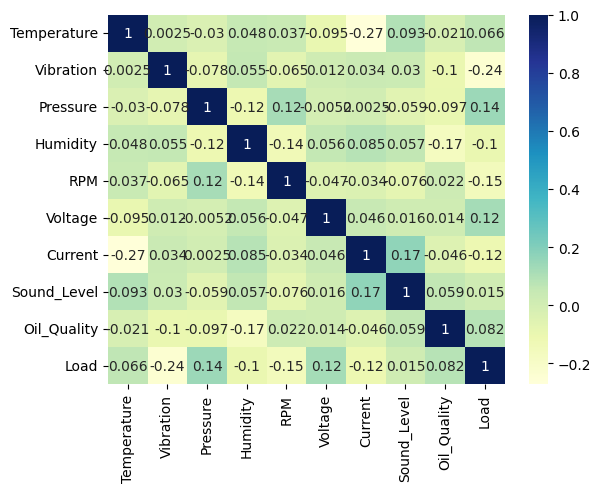

In [ ]:
# Calculate and visualize the correlation matrix.
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [ ]:
# Convert categorical columns to numerical using factorization.
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [ ]:
# Define features (X) and target (y) for the model.
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [ ]:
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train a RandomForestClassifier and evaluate its performance.
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.95
Recall: 0.95
Precision: 0.96
F1 Score: 0.9508547008547008
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4
           2       1.00      0.86      0.92         7
           3       0.80      1.00      0.89         4

    accuracy                           0.95        20
   macro avg       0.95      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



In [ ]:
# Train a RandomForestRegressor and calculate Mean Absolute Error.
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Absolute Error:', np.mean(np.abs(y_test - y_pred)))

Mean Absolute Error: 0.0


# **Bagging**

In [ ]:
# Create and train a pipeline with StandardScaler and RandomForestClassifier.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
# Evaluate the performance of the pipeline on the test set.
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.95
Recall: 0.95
Precision: 0.96
F1 Score: 0.9508547008547008
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4
           2       1.00      0.86      0.92         7
           3       0.80      1.00      0.89         4

    accuracy                           0.95        20
   macro avg       0.95      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



In [ ]:
# Perform cross-validation for the pipeline.
cv = cross_val_score(pipeline, X, y, cv=10)

print(f"Cross-validation scores: {cv}")
print(f"Mean CV accuracy: {np.mean(cv):.2f}")

Cross-validation scores: [1.  1.  0.9 1.  0.9 1.  0.8 0.9 1.  1. ]
Mean CV accuracy: 0.95


In [ ]:
# Train a BaggingClassifier with the defined pipeline.
bagging_classifier = BaggingClassifier(estimator=pipeline, n_estimators=150, random_state=42)

bagging_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                            ('classifier',
                                             RandomForestClassifier(random_state=42))]),
                  n_estimators=150, random_state=42)

In [ ]:
# Evaluate the performance of the BaggingClassifier.
y_pred = bagging_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_pred, y_test))

Accuracy: 1.0
Recall: 1.0
Precision: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
# Perform cross-validation for the BaggingClassifier.
cv = cross_val_score(bagging_classifier, X, y, cv=10)

print(f"Cross-validation scores: {cv}")
print(f"Mean CV accuracy: {np.mean(cv):.2f}")

Cross-validation scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean CV accuracy: 1.00


# **Neural Networks**

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session() # Clear the Keras session to avoid previous graph issues

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.LSTM(60, input_shape=(X_train.shape[1], 1)))
model.add(tf.keras.layers.Dense(4, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.utils import to_categorical

# One-hot encode y_train and y_test
y_train_one_hot = to_categorical(y_train, num_classes=4)
y_test_one_hot = to_categorical(y_test, num_classes=4)

# Reshape X_train and X_test for LSTM input
X_train_reshaped = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

model.fit(X_train_reshaped, y_train_one_hot, epochs=100, batch_size=35, validation_data=(X_test_reshaped, y_test_one_hot))

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.2875 - loss: 1.3998 - val_accuracy: 0.2500 - val_loss: 1.3968
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2750 - loss: 1.3910 - val_accuracy: 0.3500 - val_loss: 1.3661
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2625 - loss: 1.3849 - val_accuracy: 0.2500 - val_loss: 1.3565
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2125 - loss: 1.3827 - val_accuracy: 0.3500 - val_loss: 1.3536
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2625 - loss: 1.3803 - val_accuracy: 0.4000 - val_loss: 1.3536
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2875 - loss: 1.3729 - val_accuracy: 0.4000 - val_loss: 1.3583
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2750 - loss: 1.3654 - val_accuracy: 0.4000 - val_loss: 1.3659
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2875 - loss: 1.3625 - val_accuracy: 0.4000 - val_loss